In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from Constants import Const
import SymptomPreprocessing as Symptom
import re

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
#preface: the goal of this part is to do the preprocessing to get the data needed for the clustering
temp = pd.read_csv(Const.data_dir+'minimal_dose_cluster_dataset.csv')
#the version I use has a bunch of optional preprocessing stuff
#main things: id, dose values ("DX" or "VX"), demographics + treatment info, and symptoms (symptoms_<name>)
#included in this exampe is also non-imputed symptoms (symptoms_<name>_original), and experimental symptom groups which will not be done in this notebook code example
for col in temp.columns:
    #skip similar values for the symptoms ect
    if 'symptoms' in col and 'drymouth' not in col:
        continue
    if len(col) == 3 and col[0] in ['V','D']:
        continue
    print(col,temp[col].iloc[0])
    print()

id 2

D2 [54.53125, 28.1875, 59.84375, 57.40625, 55.9375, 63.71875, 56.125, 73.1875, 26.53125, 70.375, 71.0625, 60.875, 55.90625, 56.125, 63.46875, 43.90625, 36.6875, 72.5625, 58.84375, 67.8125, 72.375, 73.0, 61.5, 60.875, 73.0625, 72.875, 64.9375, 72.5625, 73.1875, 72.375, 72.625, 58.90625, 72.375, 72.1875, 72.5625, 71.875, 52.875, 35.5625, 20.453125, 48.5625]

D5 [53.21875, 27.4375, 58.28125, 55.5, 54.90625, 60.875, 53.3125, 73.0, 24.875, 62.65625, 69.875, 60.5, 55.71875, 52.53125, 60.84375, 38.21875, 34.8125, 72.125, 57.71875, 59.6875, 72.25, 72.625, 55.84375, 58.25, 72.5625, 72.4375, 63.90625, 72.3125, 72.8125, 72.1875, 72.3125, 51.375, 71.8125, 71.875, 72.25, 71.1875, 41.125, 32.375, 17.234375, 44.96875]

V5 [96.375, 100.0, 95.6875, 100.0, 100.0, 100.0, 100.0, 100.0, 30.71875, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 93.6875, 97.375, 100.0, 100.0, 100.0, 100.0, 100.0, 91.9375, 97.875, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 99.6875, 87.75, 100

In [4]:
#symptom data is an array that coresponds to the dates in the "dates" column, in terms of weeks since treatment start
import json
temps, tempdates = [json.loads(x) for x in temp[['symptoms_drymouth','dates']].iloc[0].tolist()]
for s,d in zip(temps,tempdates):
    print('symptoms at '+str(d) + ' weeks: ' + str(s) + ' out of 10')

symptoms at 0 weeks: 0.0 out of 10
symptoms at 1 weeks: 3.0 out of 10
symptoms at 2 weeks: 2.0 out of 10
symptoms at 3 weeks: 3.0 out of 10
symptoms at 4 weeks: 4.0 out of 10
symptoms at 5 weeks: 4.0 out of 10
symptoms at 6 weeks: 4.0 out of 10
symptoms at 7 weeks: 4.0 out of 10
symptoms at 13 weeks: 8.0 out of 10
symptoms at 33 weeks: 4.0 out of 10
symptoms at 59 weeks: 3.0 out of 10
symptoms at 85 weeks: 5.0 out of 10
symptoms at 268 weeks: 0.0 out of 10


In [5]:
#organ values (DX, VX, mean_dose, volume), are arrays ordered by the order in Const.organ_list
#if this changes it also needs to be reflected in the Constants in the react frontend
for value, organ in zip(json.loads(temp.D15.iloc[0]), Const.organ_list):
    print('D15 to '  + organ + ': ' + str(value) + ' greys')

D15 to Esophagus: 49.78125 greys
D15 to Spinal_Cord: 26.515625 greys
D15 to Lt_Brachial_Plexus: 54.6875 greys
D15 to Rt_Brachial_Plexus: 52.21875 greys
D15 to Cricopharyngeal_Muscle: 52.96875 greys
D15 to Cricoid_cartilage: 56.1875 greys
D15 to IPC: 47.5 greys
D15 to MPC: 72.3125 greys
D15 to Brainstem: 19.703125 greys
D15 to Larynx: 54.21875 greys
D15 to Thyroid_cartilage: 64.0 greys
D15 to Rt_Sternocleidomastoid_M: 60.03125 greys
D15 to Rt_Mastoid: 54.5 greys
D15 to Rt_Parotid_Gland: 42.09375 greys
D15 to Rt_Medial_Pterygoid_M: 56.53125 greys
D15 to Rt_Lateral_Pterygoid_M: 31.65625 greys
D15 to Rt_Masseter_M: 31.953125 greys
D15 to Lt_Sternocleidomastoid_M: 70.9375 greys
D15 to Lt_Mastoid: 54.125 greys
D15 to Lt_Parotid_Gland: 43.65625 greys
D15 to Lt_Submandibular_Gland: 72.0 greys
D15 to Lt_Medial_Pterygoid_M: 72.125 greys
D15 to Lt_Lateral_Pterygoid_M: 42.46875 greys
D15 to Lt_Masseter_M: 52.375 greys
D15 to Supraglottic_Larynx: 72.0625 greys
D15 to SPC: 71.9375 greys
D15 to Rt_Su

In [6]:
#Dataset provided is a row for each organ, with ID, and dose information

In [3]:
base_df = pd.read_excel(Const.data_dir + 'Cohort_SMART2_530pts_(486pts).xlsx')
# base_df = pd.read_csv(Const.data_dir + 'dvh_20260421.csv')
base_df.head()

,id,Structure,DicomType,Volume,mean,minGy,maxGy,V5,V10,V15,...,D65,D70,D75,D80,D85,D90,D95,D97,D98,D99
0,2.0,A_Carotid_Int_L,ORGAN,894.012451,67.978157,6079,7174,100,100,100,...,67.48,66.45,65.63,64.69,63.88,62.76,61.83,61.41,61.02,60.82
1,2.0,A_Carotid_Int_R,ORGAN,53.558350,58.114615,5708,5917,100,100,100,...,58.04,57.92,57.5,57.5,57.37,57.09,57.09,0.01,0.01,0.01
2,2.0,Bone_Hyoid,ORGAN,2101.135254,69.126667,5626,7282,100,100,100,...,68.33,67.79,67.41,66.67,65.82,64.58,62.16,60.3,59.82,58.32
3,2.0,Bone_Manubrium,ORGAN,36897.583008,30.844799,394,6735,96.237159,77.690933,69.305494,...,18.6,14.83,13.46,9.46,8.44,6.51,5.15,4.91,4.77,4.2
4,2.0,Bone_Mastoid_L,ORGAN,1557.312012,44.221032,1765,6038,100,100,100,...,41.74,39.99,38.44,36.03,33.2,29.16,23.8,22.44,20.77,18.41


In [4]:
# I map the names here to the original names in CAMPRT (originally for use with the spatial data, can be ignored if redone)
# The current code has a spellchecker, which is redundant with this list
organ_rename_dict = {
    "cricoid": "Cricoid_cartilage",
    "cricopharyngeus": "Cricopharyngeal_Muscle",
    "esophagus_u": "Esophagus",
    "oral_cavity": "Extended_Oral_Cavity",
    "musc_geniogloss": "Genioglossus_M",
    "hardpalate": "Hard_Palate",
    "bone_hyoid": "Hyoid_bone",
    "musc_constrict_i": "IPC",
    "lips_lower": "Lower_Lip",
    "lips_upper": "Upper_Lip",
    "musc_constrict_m": "MPC",
    "musc_mgh_complex": "Mylogeniohyoid_M",
    "musc_mghcomplex": "Mylogeniohyoid_M",
    "palate_soft": "Soft_Palate",
    "musc_constrict_s": "SPC",
    "spinalcord_cerv": "Spinal_Cord",
    "larynx_sg": "Supraglottic_Larynx",
    "cartlg_thyroid": "Thyroid_cartilage",
    "brachial_plex_r": "Rt_Brachial_Plexus",
    "brachial_plex_l": "Lt_Brachial_Plexus",
    "pterygoid_lat_r": "Rt_Lateral_Pterygoid_M",
    "pterygoid_lat_l": "Lt_Lateral_Pterygoid_M",
    "musc_masseter_r": "Rt_Masseter_M",
    "musc_masseter_l": "Lt_Masseter_M",
    "bone_mastoid_r": "Rt_Mastoid",
    "bone_mastoid_l": "Lt_Mastoid",
    "pterygoid_med_r": "Rt_Medial_Pterygoid_M",
    "pterygoid_med_l": "Lt_Medial_Pterygoid_M",
    "parotid_r": "Rt_Parotid_Gland",
    "parotid_l": "Lt_Parotid_Gland",
    "musc_sclmast_r": "Rt_Sternocleidomastoid_M",
    "musc_sclmast_l": "Lt_Sternocleidomastoid_M",
    "glnd_submand_r": "Rt_Submandibular_Gland",
    "glnd_submand_l": "Lt_Submandibular_Gland",
    "musc_digastric_ra": "Rt_Ant_Digastric_M",
    "musc_digastric_la": "Lt_Ant_Digastric_M",
    "musc_digastric_rp": "Rt_Post_Digastric_M",
    "musc_digastric_lp": "Lt_Post_Digastric_M",
}

In [5]:
#rename headers to be consisent with CAMPRT Dataset
file_header_renames = {
        'mean': 'mean_dose',
        'Volume': 'volume',
        'minGy': 'min_dose',
        'maxGy': 'max_dose',
    }
df = base_df.rename(file_header_renames,axis=1)
df['ROI'] = df.Structure.apply(lambda x: organ_rename_dict.get(x.lower(),x))
df = df[df['DicomType'] =='ORGAN'].drop('DicomType',axis=1)
df.head()

,id,Structure,volume,mean_dose,min_dose,max_dose,V5,V10,V15,V20,...,D70,D75,D80,D85,D90,D95,D97,D98,D99,ROI
0,2.0,A_Carotid_Int_L,894.012451,67.978157,6079,7174,100,100,100,100,...,66.45,65.63,64.69,63.88,62.76,61.83,61.41,61.02,60.82,A_Carotid_Int_L
1,2.0,A_Carotid_Int_R,53.558350,58.114615,5708,5917,100,100,100,100,...,57.92,57.5,57.5,57.37,57.09,57.09,0.01,0.01,0.01,A_Carotid_Int_R
2,2.0,Bone_Hyoid,2101.135254,69.126667,5626,7282,100,100,100,100,...,67.79,67.41,66.67,65.82,64.58,62.16,60.3,59.82,58.32,Hyoid_bone
3,2.0,Bone_Manubrium,36897.583008,30.844799,394,6735,96.237159,77.690933,69.305494,62.907548,...,14.83,13.46,9.46,8.44,6.51,5.15,4.91,4.77,4.2,Bone_Manubrium
4,2.0,Bone_Mastoid_L,1557.312012,44.221032,1765,6038,100,100,100,98.941799,...,39.99,38.44,36.03,33.2,29.16,23.8,22.44,20.77,18.41,Lt_Mastoid


<Axes: >

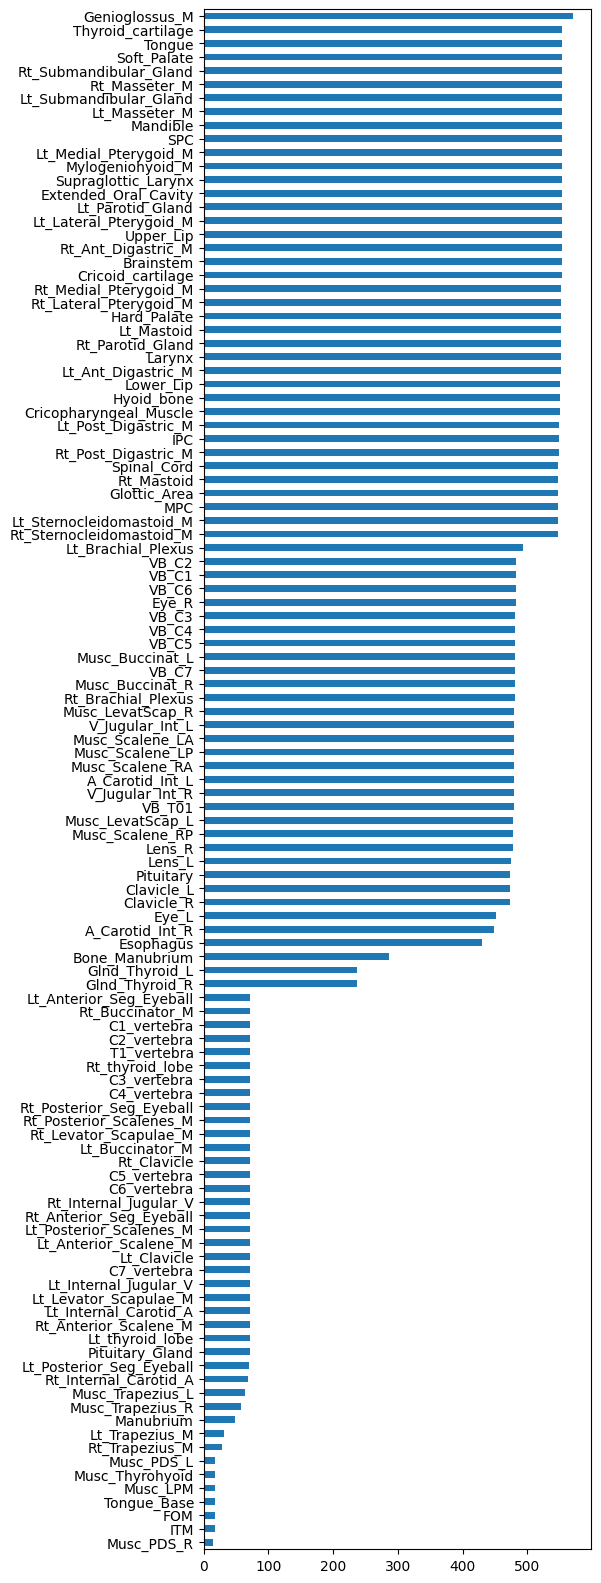

In [6]:
#The organ counts are variable. and have name inconsistencies. These will probably be different on a different dataset
organ_counts = {}
for _,row in df.iterrows():
    count = organ_counts.get(row['ROI'],0)
    organ_counts[row['ROI']] = count + 1
pd.Series(organ_counts).sort_values().plot(kind='barh',ax=plt.subplots(1,1,figsize=(5,20))[1])

In [7]:
#For reference, I use a static organ list that is the organs I select for and is also a fixed order for arrays of organ values
Const.organ_list

['Esophagus',
 'Spinal_Cord',
 'Lt_Brachial_Plexus',
 'Rt_Brachial_Plexus',
 'Cricopharyngeal_Muscle',
 'Cricoid_cartilage',
 'IPC',
 'MPC',
 'Brainstem',
 'Larynx',
 'Thyroid_cartilage',
 'Rt_Sternocleidomastoid_M',
 'Rt_Mastoid',
 'Rt_Parotid_Gland',
 'Rt_Medial_Pterygoid_M',
 'Rt_Lateral_Pterygoid_M',
 'Rt_Masseter_M',
 'Lt_Sternocleidomastoid_M',
 'Lt_Mastoid',
 'Lt_Parotid_Gland',
 'Lt_Submandibular_Gland',
 'Lt_Medial_Pterygoid_M',
 'Lt_Lateral_Pterygoid_M',
 'Lt_Masseter_M',
 'Supraglottic_Larynx',
 'SPC',
 'Rt_Submandibular_Gland',
 'Hyoid_bone',
 'Soft_Palate',
 'Genioglossus_M',
 'Tongue',
 'Rt_Ant_Digastric_M',
 'Lt_Ant_Digastric_M',
 'Mylogeniohyoid_M',
 'Extended_Oral_Cavity',
 'Mandible',
 'Hard_Palate',
 'Lower_Lip',
 'Upper_Lip',
 'Glottic_Area']

In [12]:
#In the dass code, the spellchecker was there to fix organ names and align them with the CAMPRT dataset, 
#which is what I was working on at the beginning of the project
#Furture projects will probably have a seperate thing.

In [8]:
#General Data Cleanup, may be required in future datasets
#enforce value columns to be numbers
def fix_df(df):
    df = df.drop_duplicates(subset=['id','ROI','volume'])
    df = df[df.mean_dose != 'error']
    #make sure volume and dose fields are actual numbers
    for col in df.columns:
        if 'dose' in col.lower() or 'volume' in col.lower():
            df[col] = df[col].astype(float)
    hist_cols = [c for c in df.columns if (re.match(r'[DV]\d+',c) is not None)]
    df[hist_cols] = df[hist_cols].astype('float16')
    df = df[~df.id.isna()]
    df['id'] = df.id.astype(int)
    return df
    

df = fix_df(df)
df.head()

/Users/siyuanzhao/anaconda3/envs/VDS/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/Users/siyuanzhao/anaconda3/envs/VDS/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,id,Structure,volume,mean_dose,min_dose,max_dose,V5,V10,V15,V20,...,D70,D75,D80,D85,D90,D95,D97,D98,D99,ROI
0,2,A_Carotid_Int_L,894.012451,67.978157,6079.0,7174.0,100.00,100.0000,100.0000,100.00000,...,66.437500,65.625000,64.687500,63.8750,62.750000,61.843750,61.406250,61.031250,60.812500,A_Carotid_Int_L
1,2,A_Carotid_Int_R,53.558350,58.114615,5708.0,5917.0,100.00,100.0000,100.0000,100.00000,...,57.906250,57.500000,57.500000,57.3750,57.093750,57.093750,0.010002,0.010002,0.010002,A_Carotid_Int_R
2,2,Bone_Hyoid,2101.135254,69.126667,5626.0,7282.0,100.00,100.0000,100.0000,100.00000,...,67.812500,67.437500,66.687500,65.8125,64.562500,62.156250,60.312500,59.812500,58.312500,Hyoid_bone
3,2,Bone_Manubrium,36897.583008,30.844799,394.0,6735.0,96.25,77.6875,69.3125,62.90625,...,14.828125,13.460938,9.460938,8.4375,6.511719,5.148438,4.910156,4.769531,4.199219,Bone_Manubrium
4,2,Bone_Mastoid_L,1557.312012,44.221032,1765.0,6038.0,100.00,100.0000,100.0000,98.93750,...,40.000000,38.437500,36.031250,33.1875,29.156250,23.796875,22.437500,20.765625,18.406250,Lt_Mastoid


In [9]:
def filter_valid_patients(df,organ_list, max_missing_ratio=.5,print_out=True):
    df = df.copy()
    dfs = []
    for pid,subdf in df.groupby('id'):
        
        rois = set([i for i in np.unique(subdf.ROI) if i in organ_list])
        n_rois = len(rois)
        n_missing = np.abs(n_rois - len(organ_list))
        if print_out:
            if n_missing != 0:
                print('patient ', pid, 'has', n_missing,'organs off')
        if subdf[subdf.duplicated(subset=['ROI','Structure'],keep=False)].loc[:,['ROI','Structure']].shape[0] > 0:
            print('patient',pid,'has duplicate organs?')
            print(subdf[subdf.duplicated(subset=['ROI','Structure'],keep=False)].loc[:,['ROI','Structure']])
        max_missing = len(organ_list)*max_missing_ratio
        flag = (n_missing < max_missing)
        if flag:
            dfs.append(subdf)
    valid_df = pd.concat(dfs)
    print('valid patients:',len(valid_df.id.unique()),'out of',len(df.id.unique()))
    return valid_df

##This code filters patients based on certain missing values. Here are removing people with more than half the organs in Const.organ_list
filtered_df = filter_valid_patients(df,Const.organ_list,print_out=False)

valid patients: 464 out of 485


In [10]:
#add in missing organs from organ_list for each patient
#so when we turn it into an array the values will be there
#by default, these are nan
def add_patient_organs(pid,patient_df,organ_list):
    pdf = patient_df.copy()
    rois = np.unique(patient_df.ROI.values)
    for organ in organ_list:
        if organ not in rois:
            entry = pd.Series([pid,'missing',organ],index=['id','Structure','ROI'])
            pdf = pd.concat([pd.DataFrame(entry).T,pdf],ignore_index=True)
    return pdf

def add_missing_organs(df,organ_list):
    dfs = []
    for pid,subdf in df.groupby('id'):
        subdf = add_patient_organs(pid,subdf,organ_list).set_index("ROI")
        subdf = subdf.loc[organ_list]
        subdf = subdf.reset_index()
        dfs.append(subdf)
    return pd.concat(dfs)

clean_df = add_missing_organs(filtered_df,Const.organ_list)
clean_df.head()

/Users/siyuanzhao/anaconda3/envs/VDS/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/Users/siyuanzhao/anaconda3/envs/VDS/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,ROI,id,Structure,volume,mean_dose,min_dose,max_dose,V5,V10,V15,...,D65,D70,D75,D80,D85,D90,D95,D97,D98,D99
0,Esophagus,2,Esophagus_U,14279.479980,35.720554,297.0,5827.0,96.3750,91.5625,88.25,...,34.000000,33.03125,31.812500,29.187500,21.34375,13.140625,6.160156,4.710938,4.011719,3.500000
1,Spinal_Cord,2,SpinalCord_Cerv,12866.363525,23.816881,1768.0,3008.0,100.0000,100.0000,100.00,...,23.015625,22.68750,22.359375,21.984375,21.53125,20.906250,19.453125,18.781250,18.453125,18.062500
2,Lt_Brachial_Plexus,2,Brachial_Plex_L,7139.739990,36.247807,341.0,6272.0,95.6875,80.0000,75.50,...,35.468750,25.65625,16.375000,9.968750,7.46875,6.308594,5.230469,4.621094,4.199219,3.960938
3,Rt_Brachial_Plexus,2,Brachial_Plex_R,5500.030518,42.946247,1308.0,6034.0,100.0000,100.0000,99.00,...,40.750000,39.12500,37.125000,34.812500,32.31250,29.734375,26.031250,22.312500,20.515625,14.953125
4,Cricopharyngeal_Muscle,2,Cricopharyngeus,2698.516846,49.904351,4070.0,5747.0,100.0000,100.0000,100.00,...,49.218750,48.81250,48.187500,47.781250,46.68750,45.000000,43.031250,42.593750,41.906250,41.187500


In [ ]:
def get_value_array(
    df, cols, organ_list, input_median=True, rows="patients", as_df=True
):
    # returns a value array, with rows=patients, it will roll up the organs for a patient
    # keep_d2 set to false will return a 3d matrix where the second dimension is the organs in same order as organ list
    # as_df needs to be 2d, will include headers and ID
    # cols is the value arrays to inclue from
    if "Structure" in cols or "ROI" in cols:
        cols = list(set(cols) - set(["Structure", "ROI"]))
    cols = [c for c in cols if c not in ["Structure", "ROI", "id"]]
    try:
        subdf = df[cols].astype(float)
        subdf["id"] = df.id
        subdf["ROI"] = df["ROI"]
        subdf = subdf[subdf.ROI.isin(organ_list)]
    except Exception as e:
        print("error getting values as floats")
        print(e)
    if input_median:
        for col in cols:
            nanvals = np.isnan(subdf[col])
            subdf.loc[nanvals, col] = subdf[~nanvals][col].median()
    if rows == "organs":
        if as_df:
            return subdf
        else:
            return subdf.drop(["id", "ROI"], axis=1).values
    else:
        assert rows == "patients"
        values = []
        pids = sorted(subdf.id.unique())
        colnames = []
        for roi in subdf.ROI.unique():
            for c in subdf.columns:
                if c != "id" and c != "ROI":
                    colnames.append(roi + "_" + c)
        for pid in pids:
            pdf = subdf[subdf.id == pid]
            #             for pid, pdf in subdf.groupby('id'):
            #                 pids.append(pid)
            pdf = pdf[pdf.ROI.apply(lambda x: x in organ_list)]
            rows = pdf.drop(["id", "ROI"], axis=1)
            values.append(rows.values.ravel())
        if as_df:
            returndf = pd.DataFrame(np.array(values), index=pids, columns=colnames)
            returndf.index.name = "id"
            return returndf
        else:
            values = np.array(values)
            return values


# this will roll up the dvh dataframe to be per-patient instead of per ROI
# second argument is the list of columns to input
# third argument is list of organs
get_value_array(clean_df, list(clean_df.columns), Const.organ_list).head()

,Esophagus_D25,Esophagus_D90,Esophagus_D30,Esophagus_V20,Esophagus_V15,Esophagus_D10,Esophagus_D15,Esophagus_V30,Esophagus_D97,Esophagus_D20,...,Glottic_Area_V60,Glottic_Area_D99,Glottic_Area_max_dose,Glottic_Area_D95,Glottic_Area_D65,Glottic_Area_D35,Glottic_Area_V40,Glottic_Area_D85,Glottic_Area_V5,Glottic_Area_D45
id,,,,,,,,,,,,,,,,,,,,,
2,44.437500,13.140625,42.53125,85.6875,88.25000,51.625000,49.781250,78.93750,4.710938,47.093750,...,0.0,15.648438,5334.0,15.929688,19.515625,26.968750,9.726562,17.015625,100.0,23.953125
6,41.437500,3.509766,40.37500,72.5625,75.37500,44.968750,44.031250,70.31250,2.189453,42.781250,...,0.0,28.125000,4654.0,28.734375,31.375000,33.406250,9.710938,29.906250,100.0,32.593750
7,34.062500,3.210938,33.12500,61.5000,64.75000,37.625000,36.562500,49.06250,0.020004,35.250000,...,0.0,27.343750,3156.0,27.500000,28.625000,29.593750,0.000000,27.984375,100.0,29.062500
8,30.609375,6.078125,29.93750,49.1875,55.34375,32.156250,31.703125,29.53125,4.468750,31.203125,...,0.0,6.691406,2849.0,7.308594,10.390625,14.343750,0.000000,8.390625,100.0,14.000000
9,43.593750,18.312500,41.34375,86.1875,96.50000,51.484375,48.640625,59.46875,14.570312,46.078125,...,0.0,5.621094,3452.0,5.750000,6.281250,18.640625,0.000000,5.921875,100.0,15.671875


In [12]:
#we can also use a subset of the organs and dose values
def get_dvh_columns(df,key,steps=None):
        good_cols = []
        dvh=df.copy()
        for c in dvh.columns:
            match = re.match(key+r'(\d+)', c)
            if match is not None:
                use = True
                if steps is not None and match.group(1) is not None:
                    value = int(match.group(1))
                    if value not in steps:
                        use = False
                if use:
                    good_cols.append(match.group(0))
        keys = sorted(good_cols, key = get_dvhcol_pos)
        pos = [get_dvhcol_pos(x) for x in good_cols]
        return keys, pos
    
def get_dvhcol_pos(x):
    m = re.match('[DV]'+r'(\d+)',x)
    if m is not None:
        return int(m.group(1))
    else:
        return -1
#this extracts the sorted values for dose volume histograms from the dataframe columns
#key is either 'V' (for volume) or 'D' (for dose). DASS uses 'D'
get_dvh_columns(clean_df,'D')

(['D2',
  'D5',
  'D10',
  'D15',
  'D20',
  'D25',
  'D30',
  'D35',
  'D40',
  'D45',
  'D50',
  'D55',
  'D60',
  'D65',
  'D70',
  'D75',
  'D80',
  'D85',
  'D90',
  'D95',
  'D97',
  'D98',
  'D99'],
 [2,
  5,
  10,
  15,
  20,
  25,
  30,
  35,
  40,
  45,
  50,
  55,
  60,
  65,
  70,
  75,
  80,
  85,
  90,
  95,
  97,
  98,
  99])

In [13]:
#We can thus get a subset of the organ dose values
get_value_array(clean_df,get_dvh_columns(clean_df,'D')[0],['Extended_Oral_Cavity','Esophagus']).head()

,Esophagus_D2,Esophagus_D5,Esophagus_D10,Esophagus_D15,Esophagus_D20,Esophagus_D25,Esophagus_D30,Esophagus_D35,Esophagus_D40,Esophagus_D45,...,Extended_Oral_Cavity_D65,Extended_Oral_Cavity_D70,Extended_Oral_Cavity_D75,Extended_Oral_Cavity_D80,Extended_Oral_Cavity_D85,Extended_Oral_Cavity_D90,Extended_Oral_Cavity_D95,Extended_Oral_Cavity_D97,Extended_Oral_Cavity_D98,Extended_Oral_Cavity_D99
id,,,,,,,,,,,,,,,,,,,,,
2,54.53125,53.21875,51.62500,49.781250,47.093750,44.437500,42.53125,41.03125,39.781250,38.43750,...,42.78125,37.343750,33.09375,29.765625,26.375000,22.500000,18.828125,17.000000,14.898438,12.609375
6,48.06250,46.12500,44.96875,44.031250,42.781250,41.437500,40.37500,39.59375,39.093750,38.62500,...,47.50000,42.468750,38.03125,34.062500,30.281250,26.734375,22.812500,20.484375,19.031250,16.390625
7,39.96875,38.68750,37.62500,36.562500,35.250000,34.062500,33.12500,32.28125,31.609375,30.84375,...,47.06250,42.250000,38.37500,35.281250,32.406250,29.640625,26.218750,24.062500,22.593750,20.765625
8,33.43750,32.78125,32.15625,31.703125,31.203125,30.609375,29.93750,28.96875,27.187500,24.87500,...,61.43750,55.625000,50.62500,45.125000,39.312500,34.218750,30.921875,28.750000,26.937500,24.578125
9,54.53125,52.31250,49.87500,46.937500,44.343750,42.062500,40.37500,38.46875,35.843750,33.25000,...,32.31250,30.796875,29.37500,27.843750,25.984375,23.734375,21.031250,19.625000,18.703125,17.484375


In [14]:
#now we roll up the values so each column is an array (so we can compute on them more easily)
#order is order of Const.organ_list
dvh_df = get_value_array(clean_df,clean_df.columns,Const.organ_list)
cols = [c for c in clean_df.columns if c not in ['ROI','Structure','id']]
vallist = []
for col in cols:
    colnames = [o + '_' + col for o in Const.organ_list]
    valdf = dvh_df[colnames].sort_index()
    vals = valdf.values.tolist()
    vallist.append(vals)
valdf = pd.DataFrame(np.swapaxes(np.array(vallist),0,1).tolist(),index=dvh_df.index,columns=cols)
valdf.head()

,volume,mean_dose,min_dose,max_dose,V5,V10,V15,V20,V25,V30,...,D65,D70,D75,D80,D85,D90,D95,D97,D98,D99
id,,,,,,,,,,,,,,,,,,,,,
2,"[14279.47998046875, 12866.363525390625, 7139.7...","[35.72055395268319, 23.816881203970524, 36.247...","[297.0, 1768.0, 341.0, 1308.0, 4070.0, 2579.0,...","[5827.0, 3008.0, 6272.0, 6034.0, 5747.0, 6842....","[96.375, 100.0, 95.6875, 100.0, 100.0, 100.0, ...","[91.5625, 100.0, 80.0, 100.0, 100.0, 100.0, 10...","[88.25, 100.0, 75.5, 99.0, 100.0, 100.0, 100.0...","[85.6875, 93.875, 72.5625, 98.375, 100.0, 100....","[82.9375, 31.1875, 70.3125, 96.25, 100.0, 100....","[78.9375, 0.032012939453125, 68.0625, 89.375, ...",...,"[34.0, 23.015625, 35.46875, 40.75, 49.21875, 4...","[33.03125, 22.6875, 25.65625, 39.125, 48.8125,...","[31.8125, 22.359375, 16.375, 37.125, 48.1875, ...","[29.1875, 21.984375, 9.96875, 34.8125, 47.7812...","[21.34375, 21.53125, 7.46875, 32.3125, 46.6875...","[13.140625, 20.90625, 6.30859375, 29.734375, 4...","[6.16015625, 19.453125, 5.23046875, 26.03125, ...","[4.7109375, 18.78125, 4.62109375, 22.3125, 42....","[4.01171875, 18.453125, 4.19921875, 20.515625,...","[3.5, 18.0625, 3.9609375, 14.953125, 41.1875, ..."
6,"[6974.945068359375, 16417.694091796875, 6562.9...","[30.499019492025983, 22.78990464240902, 32.607...","[184.0, 1369.0, 98.0, 1356.0, 3583.0, 2759.0, ...","[5088.0, 3084.0, 6896.0, 5966.0, 6443.0, 6304....","[84.875, 100.0, 64.875, 100.0, 100.0, 100.0, 1...","[78.375, 100.0, 61.71875, 100.0, 100.0, 100.0,...","[75.375, 97.625, 59.5625, 98.9375, 100.0, 100....","[72.5625, 81.875, 58.75, 96.3125, 100.0, 100.0...","[72.4375, 25.546875, 57.875, 92.9375, 100.0, 1...","[70.3125, 0.1505126953125, 56.625, 92.6875, 10...",...,"[34.15625, 22.328125, 4.94921875, 44.71875, 43...","[30.484375, 21.84375, 3.859375, 43.6875, 42.15...","[17.09375, 21.1875, 3.220703125, 42.4375, 41.4...","[6.69921875, 20.34375, 2.66015625, 40.875, 41....","[4.390625, 19.3125, 2.060546875, 38.75, 40.593...","[3.509765625, 18.03125, 1.580078125, 34.96875,...","[2.529296875, 15.9296875, 1.240234375, 22.1093...","[2.189453125, 15.25, 1.1396484375, 19.234375, ...","[2.16015625, 14.7578125, 1.099609375, 17.20312...","[1.8701171875, 14.2578125, 1.0595703125, 14.56..."
7,"[14724.42626953125, 14765.625, 6632.9956054687...","[22.765716284275324, 33.629034598214275, 56.96...","[1.0, 2114.0, 4179.0, 3625.0, 3459.0, 2969.0, ...","[4362.0, 3864.0, 6126.0, 7216.0, 5552.0, 5877....","[80.0625, 100.0, 100.0, 100.0, 100.0, 100.0, 1...","[70.3125, 100.0, 100.0, 100.0, 100.0, 100.0, 1...","[64.75, 100.0, 100.0, 100.0, 100.0, 100.0, 100...","[61.5, 100.0, 100.0, 100.0, 100.0, 100.0, 100....","[58.03125, 98.5, 100.0, 100.0, 100.0, 100.0, 1...","[49.0625, 90.6875, 100.0, 100.0, 100.0, 99.75,...",...,"[14.7734375, 32.6875, 56.46875, 51.65625, 40.5...","[10.28125, 32.3125, 55.84375, 50.46875, 40.125...","[6.578125, 31.875, 55.09375, 49.34375, 39.7187...","[5.0, 31.40625, 54.3125, 48.125, 39.28125, 36....","[3.9609375, 30.84375, 53.375, 46.75, 38.78125,...","[3.2109375, 30.140625, 52.25, 45.0, 38.34375, ...","[2.5703125, 28.984375, 50.59375, 42.375, 37.31...","[0.0200042724609375, 27.484375, 49.53125, 41.0...","[0.01000213623046875, 25.9375, 48.75, 40.4375,...","[0.01000213623046875, 23.625, 47.75, 39.3125, ..."
8,"[10428.309631347656, 17159.777069091797, 4182....","[19.083991985203443, 21.81411015361559, 48.068...","[352.0, 572.0, 909.0, 3685.0, 599.0, 609.0, 38...","[3401.0, 3709.0, 5978.0, 7046.0, 3621.0, 4159....","[95.4375, 100.0, 100.0, 100.0, 100.0, 100.0, 1...","[61.53125, 78.6875, 99.9375, 100.0, 48.46875, ...","[55.34375, 75.625, 99.75, 100.0, 24.296875, 33...","[49.1875, 70.625, 99.0625, 100.0, 18.40625, 22...","[44.75, 47.5, 98.75, 100.0, 5.3359375, 16.25, ...","[29.53125, 21.34375, 97.75, 100.0, 3.79296875,...",...,"[8.8828125, 20.9375, 46.125, 56.40625, 7.82812...","[8.0234375, 20.109375, 45.59375, 55.84375, 7.2...","[7.28125, 16.5625, 45.0, 54.90625, 6.96875, 7....","[6.69140625, 8.15625, 44.375, 53.59375, 6.8203...","

In [16]:
#we then want to merge the data with the mdasi data
# df = load_mdasi()
mdasi_df = Symptom.load_mdasi()
# mdasi_df = Symptom.load_mdasi('../data/mdasi_20260421.csv')
mdasi_df

before drop count 823
after drop count 723


,baseline_mbs_digest,n_stage,M6_mbs_digest,concurrent,t_stage,id,subsite,hpv,is_male,ic,...,symptoms_work,symptoms_relations,symptoms_walking,symptoms_enjoy,t4,n3,BOT,Tonsil,old,digest_increase
0,NaN,n2b,NaN,1.0,t1,1,BOT,1.0,True,0.0,...,"[0.0, nan, nan, nan, nan, 0.0, 0.0, 10.0, 4.0,...","[0.0, nan, nan, nan, nan, 0.0, 0.0, 0.0, 0.0, ...","[0.0, nan, nan, nan, nan, 0.0, 3.0, 7.0, 4.0, ...","[0.0, nan, nan, nan, nan, 0.0, 3.0, 1.0, 0.0, ...",0,0,1,0,1,0
1,NaN,n0,NaN,1.0,t4,2,Tonsil,-1.0,True,0.0,...,"[nan, nan, nan, nan, nan, nan, nan, 4.0, 3.0, ...","[nan, nan, nan, nan, nan, nan, nan, 1.0, 3.0, ...","[nan, nan, nan, nan, nan, nan, nan, 1.0, 0.0, ...","[nan, nan, nan, nan, nan, nan, nan, 1.0, 3.0, ...",1,0,0,1,0,0
3,NaN,n2b,NaN,1.0,t2,4,Tonsil,1.0,False,0.0,...,"[nan, 0.0, 0.0, 3.0, 5.0, 4.0, 3.0, 4.0, 0.0, ...","[nan, 0.0, 0.0, 0.0, 0.0, 7.0, 0.0, 0.0, 0.0, ...","[nan, 0.0, 0.0, 1.0, 3.0, 5.0, 3.0, 6.0, 0.0, ...","[nan, 0.0, 7.0, 9.0, 9.0, 10.0, 9.0, 10.0, 8.0...",0,0,0,1,1,0
4,NaN,n1,NaN,1.0,t2,5,BOT,0.0,True,NaN,...,"[nan, nan, 0.0, 0.0, 5.0, 10.0, 9.0, 10.0, nan...","[nan, nan, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, nan, ...","[nan, nan, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, nan, ...","[nan, nan, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, nan, ...",0,0,1,0,0,0
5,NaN,n2b,NaN,1.0,t2,6,BOT,1.0,True,0.0,...,"[4.0, nan, nan, nan, nan, nan, nan, 9.0, nan, ...","[2.0, nan, nan, nan, nan, nan, nan, 9.0, nan, ...","[6.0, nan, nan, nan, nan, nan, nan, 5.0, nan, ...","[7.0, nan, nan, nan, nan, nan, nan, 9.0, nan, ...",0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812,NaN,NaN,NaN,0.0,NaN,813,NOS,-1.0,True,0.0,...,"[0.0, nan, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, 2.0, 1.0, 1.0, nan, ...","[1.0, nan, 1.0, 1.0, 0.0, 2.0, 2.0, 3.0, nan, ...",0,0,0,0,1,0
815,NaN,n1,NaN,0.0,tx,816,BOT,-1.0,True,1.0,...,"[0.0, 0.0, nan, 1.0, 1.0, 2.0, 0.0, 1.0, nan, ...","[0.0, 0.0, nan, 0.0, 1.0, 2.0, 0.0, 1.0, nan, ...","[0.0, 0.0, nan, 0.0, 0.0, 1.0, 0.0, 1.0, nan, ...","[0.0, 0.0, nan, 1.0, 1.0, 1.0, 1.0, 1.0, nan, ...",0,0,1,0,1,0
818,NaN,n1,NaN,NaN,t1,819,BOT,-1.0,False,0.0,...,"[0.0, 0.0, 0.0, nan, nan, 5.0, nan, nan, nan, ...","[0.0, 0.0, 0.0, nan, nan, 4.0, nan, nan, nan, ...","[0.0, 0.0, 0.0, nan, nan, 0.0, nan, nan, nan, ...","[0.0, 0.0, 0.0, nan, nan, 4.0, nan, nan, nan, ...",0,0,1,0,0,0
821,NaN,n3,NaN,1.0,t3,822,Tonsil,-1.0,True,1.0,...,"[nan, 10.0, 10.0, 10.0, 10.0, nan, nan, 0.0, 9...","[nan, 5.0, 4.0, 2.0, 2.0, nan, nan, 5.0, 1.0, ...","[nan, 9.0, 8.0, 9.0, 9.0, nan, nan, 5.0, nan, ...","[nan, 5.0, 5.0, 7.0, 9.0, nan, nan, 10.0, 10.0...",0,1,0,1,1,0


In [18]:
#The most important features here are the symptom arrays "symptoms_<symptom_name"
#There is a value for dates that is the weeks since start of treatment that corresponds to the dates of each symptom
mdasi_df.iloc[0][['symptoms_drymouth','dates']].values.tolist()

[[0.0, nan, nan, nan, nan, 1.0, 1.0, nan, 0.0, 0.0, nan, nan, nan],
 [0, 1, 2, 3, 4, 5, 6, 7, 13, 33, 59, 85, 268]]

In [19]:
#We can also train an autoencoder to predict the missing (nan) values and fill them in
#use_trained will use a saved model if it exists
#for new data, you can probably ask Guadalupe's group for their results for predicting missing symptom values
mdasi_df_imputed = Symptom.impute_symptom_df(mdasi_df,
                                             use_trained=False
                                            )
mdasi_df_imputed.iloc[0][['symptoms_drymouth','symptoms_drymouth_original','dates']].values.tolist()

[[ 0.  0.  1. ... nan nan nan]
 [ 0.  0.  1. ...  0. 10. nan]
 [ 0.  0.  1. ...  6.  4. nan]
 ...
 [ 0.  0.  1. ... nan nan nan]
 [ 1.  0.  1. ... nan nan nan]
 [ 1.  0.  1. ... nan nan nan]]
training stopped on epoch 4927_fn=<MeanBackward0>)nsor(1.6544, grad_fn=<MeanBackward0>)tensor(0.8625, grad_fn=<MeanBackward0>)tensor(0.1481, grad_fn=<MeanBackward0>)tensor(0.1298, grad_fn=<MeanBackward0>)tensor(0.0689, grad_fn=<MeanBackward0>)tensor(0.0444, grad_fn=<MeanBackward0>)

error (%) 0.796204353186502


[[0.0, 0.0, 0.0, 2.0, 0.0, 1.0, 1.0, 2.0, 0.0, 0.0, 2.0, 2.0, 0.0],
 [0.0, nan, nan, nan, nan, 1.0, 1.0, nan, 0.0, 0.0, nan, nan, nan],
 [0, 1, 2, 3, 4, 5, 6, 7, 13, 33, 59, 85, 268]]

In [20]:
mdasi_df_imputed

,baseline_mbs_digest,n_stage,M6_mbs_digest,concurrent,t_stage,id,subsite,hpv,is_male,ic,...,symptoms_skin,symptoms_sleep,symptoms_sob,symptoms_swallow,symptoms_taste,symptoms_teeth,symptoms_voice,symptoms_vomit,symptoms_walking,symptoms_work
0,NaN,n2b,NaN,1.0,t1,1,BOT,1.0,True,0.0,...,"[0.0, 1.0, 0.0, 1.0, 1.0, 2.0, 4.0, 8.0, 5.0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 7.0, 8.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 1.0, 2.0, 3.0, 7.0, 2.0, ...","[0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 3.0, 4.0, 8.0, ...","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 2.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 5.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.0, 7.0, 4.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 4.0,..."
1,NaN,n0,NaN,1.0,t4,2,Tonsil,-1.0,True,0.0,...,"[0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 5.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[3.0, 1.0, 0.0, 2.0, 4.0, 7.0, 4.0, 7.0, 4.0, ...","[0.0, 0.0, 2.0, 1.0, 4.0, 7.0, 5.0, 7.0, 5.0, ...","[1.0, 0.0, 0.0, 0.0, 2.0, 3.0, 3.0, 6.0, 4.0, ...","[0.0, 0.0, 0.0, 0.0, 1.0, 5.0, 2.0, 3.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 2.0, 3.0, 0.0, ...","[0.0, 2.0, 0.0, 0.0, 1.0, 0.0, 2.0, 1.0, 0.0, ...","[0.0, 1.0, 0.0, 0.0, 0.0, 2.0, 0.0, 4.0, 3.0, ..."
2,NaN,n2b,NaN,1.0,t2,4,Tonsil,1.0,False,0.0,...,"[0.0, 0.0, 9.0, 8.0, 7.0, 5.0, 9.0, 8.0, 4.0, ...","[3.0, 2.0, 3.0, 2.0, 0.0, 0.0, 0.0, 5.0, 7.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[2.0, 0.0, 6.0, 9.0, 9.0, 8.0, 9.0, 10.0, 10.0...","[1.0, 0.0, 3.0, 9.0, 9.0, 10.0, 9.0, 10.0, 10....","[0.0, 0.0, 4.0, 1.0, 3.0, 9.0, 7.0, 9.0, 0.0, ...","[1.0, 0.0, 0.0, 1.0, 2.0, 0.0, 0.0, 2.0, 2.0, ...","[0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 1.0, 3.0, 5.0, 3.0, 6.0, 0.0, ...","[0.0, 0.0, 0.0, 3.0, 5.0, 4.0, 3.0, 4.0, 0.0, ..."
3,NaN,n1,NaN,1.0,t2,5,BOT,0.0,True,NaN,...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, ...","[0.0, 0.0, 0.0, 10.0, 4.0, 0.0, 0.0, 0.0, 2.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[2.0, 0.0, 0.0, 10.0, 5.0, 3.0, 3.0, 10.0, 0.0...","[0.0, 0.0, 0.0, 10.0, 10.0, 10.0, 9.0, 10.0, 3...","[0.0, 0.0, 0.0, 1.0, 5.0, 1.0, 1.0, 5.0, 0.0, ...","[0.0, 0.0, 0.0, 5.0, 1.0, 0.0, 0.0, 3.0, 0.0, ...","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 5.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 5.0, 10.0, 9.0, 10.0, 0.0..."
4,NaN,n2b,NaN,1.0,t2,6,BOT,1.0,True,0.0,...,"[0.0, 0.0, 3.0, 2.0, 0.0, 1.0, 4.0, 8.0, 3.0, ...","[5.0, 3.0, 3.0, 4.0, 2.0, 5.0, 1.0, 7.0, 3.0, ...","[2.0, 2.0, 2.0, 2.0, 0.0, 1.0, 3.0, 2.0, 3.0, ...","[5.0, 1.0, 3.0, 4.0, 1.0, 4.0, 5.0, 9.0, 6.0, ...","[9.0, 2.0, 2.0, 5.0, 7.0, 7.0, 5.0, 9.0, 7.0, ...","[6.0, 0.0, 2.0, 4.0, 3.0, 0.0, 4.0, 10.0, 3.0,...","[6.0, 2.0, 2.0, 2.0, 2.0, 0.0, 1.0, 8.0, 4.0, ...","[0.0, 0.0, 0.0, 1.0, 2.0, 1.0, 2.0, 0.0, 3.0, ...","[6.0, 5.0, 2.0, 4.0, 5.0, 2.0, 2.0, 5.0, 3.0, ...","[4.0, 5.0, 4.0, 2.0, 4.0, 2.0, 3.0, 9.0, 6.0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,NaN,NaN,NaN,0.0,NaN,813,NOS,-1.0,True,0.0,...,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 2.0, 3.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 2.0, 4.0, 1.0, 4.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 3.0, 6.0, 7.0, 6.0, 4.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 1.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, ..."
719,NaN,n1,NaN,0.0,tx,816,BOT,-1.0,True,1.0,...,"[0.0, 0.0, 1.0, 1.0, 0.0, 2.0, 1.0, 0.0, 0.0, ...","[2.0, 5.0, 1.0, 2.0, 1.0, 1.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 2.0, 1.0, 0.0, ...","[0.0, 1.0, 0.0, 1.0, 4.0, 3.0, 2.0, 2.0, 3.0, ...","[0.0, 0.0, 0.0, 1

In [21]:
mdasi_df.id

0        1
1        2
3        4
4        5
5        6
      ... 
812    813
815    816
818    819
821    822
822    823
Name: id, Length: 723, dtype: int64

In [22]:
valdf.index

Index([  31,  293,  314,  337,  355,  364,  367,  384,  389,  464,
       ...
       2085, 2087, 2095, 2099, 2102, 2119, 2397, 2398, 2403, 2404],
      dtype='int64', name='id', length=319)

In [22]:
mdasi_df_imputed['id'] = mdasi_df_imputed.id.astype(int)

In [23]:
merged_df = valdf.merge(mdasi_df_imputed.set_index('id'),on='id',how='inner')
merged_df

,volume,mean_dose,min_dose,max_dose,V5,V10,V15,V20,V25,V30,...,symptoms_skin,symptoms_sleep,symptoms_sob,symptoms_swallow,symptoms_taste,symptoms_teeth,symptoms_voice,symptoms_vomit,symptoms_walking,symptoms_work
id,,,,,,,,,,,,,,,,,,,,,
2,"[14279.47998046875, 12866.363525390625, 7139.7...","[35.72055395268319, 23.816881203970524, 36.247...","[297.0, 1768.0, 341.0, 1308.0, 4070.0, 2579.0,...","[5827.0, 3008.0, 6272.0, 6034.0, 5747.0, 6842....","[96.375, 100.0, 95.6875, 100.0, 100.0, 100.0, ...","[91.5625, 100.0, 80.0, 100.0, 100.0, 100.0, 10...","[88.25, 100.0, 75.5, 99.0, 100.0, 100.0, 100.0...","[85.6875, 93.875, 72.5625, 98.375, 100.0, 100....","[82.9375, 31.1875, 70.3125, 96.25, 100.0, 100....","[78.9375, 0.032012939453125, 68.0625, 89.375, ...",...,"[0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 5.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[3.0, 1.0, 0.0, 2.0, 4.0, 7.0, 4.0, 7.0, 4.0, ...","[0.0, 0.0, 2.0, 1.0, 4.0, 7.0, 5.0, 7.0, 5.0, ...","[1.0, 0.0, 0.0, 0.0, 2.0, 3.0, 3.0, 6.0, 4.0, ...","[0.0, 0.0, 0.0, 0.0, 1.0, 5.0, 2.0, 3.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 2.0, 3.0, 0.0, ...","[0.0, 2.0, 0.0, 0.0, 1.0, 0.0, 2.0, 1.0, 0.0, ...","[0.0, 1.0, 0.0, 0.0, 0.0, 2.0, 0.0, 4.0, 3.0, ..."
6,"[6974.945068359375, 16417.694091796875, 6562.9...","[30.499019492025983, 22.78990464240902, 32.607...","[184.0, 1369.0, 98.0, 1356.0, 3583.0, 2759.0, ...","[5088.0, 3084.0, 6896.0, 5966.0, 6443.0, 6304....","[84.875, 100.0, 64.875, 100.0, 100.0, 100.0, 1...","[78.375, 100.0, 61.71875, 100.0, 100.0, 100.0,...","[75.375, 97.625, 59.5625, 98.9375, 100.0, 100....","[72.5625, 81.875, 58.75, 96.3125, 100.0, 100.0...","[72.4375, 25.546875, 57.875, 92.9375, 100.0, 1...","[70.3125, 0.1505126953125, 56.625, 92.6875, 10...",...,"[0.0, 0.0, 3.0, 2.0, 0.0, 1.0, 4.0, 8.0, 3.0, ...","[5.0, 3.0, 3.0, 4.0, 2.0, 5.0, 1.0, 7.0, 3.0, ...","[2.0, 2.0, 2.0, 2.0, 0.0, 1.0, 3.0, 2.0, 3.0, ...","[5.0, 1.0, 3.0, 4.0, 1.0, 4.0, 5.0, 9.0, 6.0, ...","[9.0, 2.0, 2.0, 5.0, 7.0, 7.0, 5.0, 9.0, 7.0, ...","[6.0, 0.0, 2.0, 4.0, 3.0, 0.0, 4.0, 10.0, 3.0,...","[6.0, 2.0, 2.0, 2.0, 2.0, 0.0, 1.0, 8.0, 4.0, ...","[0.0, 0.0, 0.0, 1.0, 2.0, 1.0, 2.0, 0.0, 3.0, ...","[6.0, 5.0, 2.0, 4.0, 5.0, 2.0, 2.0, 5.0, 3.0, ...","[4.0, 5.0, 4.0, 2.0, 4.0, 2.0, 3.0, 9.0, 6.0, ..."
7,"[14724.42626953125, 14765.625, 6632.9956054687...","[22.765716284275324, 33.629034598214275, 56.96...","[1.0, 2114.0, 4179.0, 3625.0, 3459.0, 2969.0, ...","[4362.0, 3864.0, 6126.0, 7216.0, 5552.0, 5877....","[80.0625, 100.0, 100.0, 100.0, 100.0, 100.0, 1...","[70.3125, 100.0, 100.0, 100.0, 100.0, 100.0, 1...","[64.75, 100.0, 100.0, 100.0, 100.0, 100.0, 100...","[61.5, 100.0, 100.0, 100.0, 100.0, 100.0, 100....","[58.03125, 98.5, 100.0, 100.0, 100.0, 100.0, 1...","[49.0625, 90.6875, 100.0, 100.0, 100.0, 99.75,...",...,"[0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 5.0, 7.0, 0.0, ...","[0.0, 2.0, 5.0, 2.0, 1.0, 2.0, 2.0, 3.0, 1.0, ...","[3.0, 1.0, 2.0, 1.0, 2.0, 1.0, 3.0, 0.0, 1.0, ...","[0.0, 0.0, 1.0, 4.0, 6.0, 2.0, 8.0, 4.0, 2.0, ...","[5.0, 3.0, 3.0, 5.0, 8.0, 6.0, 7.0, 7.0, 6.0, ...","[2.0, 0.0, 0.0, 3.0, 3.0, 0.0, 0.0, 0.0, 1.0, ...","[0.0, 1.0, 1.0, 1.0, 2.0, 2.0, 4.0, 2.0, 1.0, ...","[0.0, 0.0, 0.0, 1.0, 5.0, 0.0, 2.0, 2.0, 0.0, ...","[0.0, 0.0, 0.0, 2.0, 1.0, 1.0, 1.0, 0.0, 1.0, ...","[0.0, 0.0, 0.0, 1.0, 2.0, 0.0, 2.0, 1.0, 2.0, ..."
8,"[10428.309631347656, 17159.777069091797, 4182....","[19.083991985203443, 21.81411015361559, 48.068...","[352.0, 572.0, 909.0, 3685.0, 599.0, 609.0, 38...","[3401.0, 3709.0, 5978.0, 7046.0, 3621.0, 4159....","[95.4375, 100.0, 100.0, 100.0, 100.0, 100.0, 1...","[61.53125, 78.6875, 99.9375, 100.0, 48.46875, ...","[55.34375, 75.625, 99.75, 100.0, 24.296875, 33...","[49.1875, 70.625, 99.0625, 100.0, 18.40625, 22...","[44.75, 47.5, 98.75, 100.0, 5.3359375, 16.25, ...","[29.53125, 21.34375, 97.75, 100.0, 3.79296875,...",...,"[0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 2.0, 6.0, 1.0, ...","[2.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 3.0, 

In [26]:
from pathlib import Path

_candidates = (
    Path.cwd() / "Cohort_SMART2_530pts_(486pts) - STIEFEL_ID_Anonymized_20260421.xlsx",
    Path.cwd().parent / "Cohort_SMART2_530pts_(486pts) - STIEFEL_ID_Anonymized_20260421.xlsx",
)
_COHORT_STIEFEL_XLSX = next((p for p in _candidates if p.is_file()), _candidates[-1])

_stiefel_map = (
    pd.read_excel(_COHORT_STIEFEL_XLSX, sheet_name=0, usecols=["id", "Stiefel_ID"])
    .drop_duplicates(subset=["id"])
)
_stiefel_map["_id_key"] = _stiefel_map["id"].astype(float)

merged_df = merged_df.copy()
# `valdf` uses patient id as the index name `id`, so after merge `id` may be the index, not a column.
_restore_id_as_index = False
if "id" not in merged_df.columns:
    if merged_df.index.name == "id":
        merged_df = merged_df.reset_index()
        _restore_id_as_index = True
    else:
        raise ValueError(
            "merged_df has no 'id' column. Expected column 'id' or an index named 'id'. "
            f"index.name={merged_df.index.name!r}"
        )

_orig_id = merged_df["id"].copy()
merged_df["_id_key"] = pd.to_numeric(merged_df["id"], errors="coerce").astype(float)
merged_df = merged_df.merge(
    _stiefel_map[["_id_key", "Stiefel_ID"]],
    on="_id_key",
    how="left",
    validate="m:1",
)
_missing = merged_df["Stiefel_ID"].isna()
if _missing.any():
    _bad = _orig_id[_missing].drop_duplicates().tolist()
    print(
        f"Warning: {_missing.sum()} row(s) had no Stiefel_ID match; "
        f"unique id values: {_bad[:40]}"
        + (" ..." if len(_bad) > 40 else "")
    )

merged_df["id"] = merged_df["Stiefel_ID"].fillna(_orig_id)

merged_df = merged_df.drop(columns=["_id_key", "Stiefel_ID"])

merged_df["id"] = (
    merged_df["id"]
    .astype(str)
    .str.replace("STIEFEL_", "", regex=False)
    .astype(int)
)

if _restore_id_as_index:
    merged_df = merged_df.set_index("id")

In [25]:
merged_df

,volume,mean_dose,min_dose,max_dose,V5,V10,V15,V20,V25,V30,...,symptoms_skin,symptoms_sleep,symptoms_sob,symptoms_swallow,symptoms_taste,symptoms_teeth,symptoms_voice,symptoms_vomit,symptoms_walking,symptoms_work
id,,,,,,,,,,,,,,,,,,,,,
293,"[10.9552, 13.9928, 5.0895, 4.7588, 2.0014, 4.9...","[23.1021, 20.6445, 55.5086, 46.1196, 26.804, 2...","[2.9, 0.5, 32.3, 20.9, 16.1, 13.7, 14.5, 19.7,...","[45.9, 35.3, 71.3, 58.3, 50.5, 54.9, 50.5, 70....","[92.4375, 81.6875, 100.0, 100.0, 100.0, 100.0,...","[85.75, 78.5, 100.0, 100.0, 100.0, 100.0, 100....","[80.75, 71.625, 100.0, 100.0, 100.0, 93.875, 9...","[75.9375, 62.46875, 100.0, 100.0, 87.1875, 72....","[49.21875, 49.65625, 100.0, 98.875, 57.09375, ...","[17.578125, 23.234375, 100.0, 96.4375, 22.0, 4...",...,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 8.0, 0.0, ...","[1.0, 2.0, 2.0, 1.0, 3.0, 8.0, 3.0, 0.0, 6.0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 3.0, 1.0, 0.0, 10.0, 1.0, 8.0, 1.0,...","[0.0, 0.0, 2.0, 1.0, 10.0, 10.0, 2.0, 9.0, 3.0...","[0.0, 0.0, 1.0, 1.0, 0.0, 9.0, 1.0, 7.0, 2.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 4.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 3.0, 0.0, ..."
314,"[5.9096, 9.3555, 5.6902, 5.2043, 2.2005, 5.754...","[27.8588, 23.6933, 64.4976, 55.6087, 34.1972, ...","[16.3, 1.3, 40.5, 30.1, 26.9, 18.1, 21.5, 47.3...","[51.9, 38.3, 73.1, 61.5, 53.7, 57.5, 70.3, 71....","[100.0, 92.25, 100.0, 100.0, 100.0, 100.0, 100...","[100.0, 88.9375, 100.0, 100.0, 100.0, 100.0, 1...","[100.0, 78.4375, 100.0, 100.0, 100.0, 100.0, 1...","[88.875, 72.1875, 100.0, 100.0, 100.0, 97.25, ...","[65.1875, 59.25, 100.0, 100.0, 100.0, 79.3125,...","[30.359375, 28.828125, 100.0, 100.0, 68.0, 49....",...,"[0.0, 0.0, 3.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, ...","[2.0, 0.0, 3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 1.0, 0.0, 3.0, 0.0, 2.0, 2.0, ...","[0.0, 0.0, 2.0, 1.0, 0.0, 1.0, 3.0, 2.0, 9.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 2.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[1.0, 1.0, 3.0, 2.0, 2.0, 1.0, 0.0, 0.0, 2.0, ..."
337,"[16.0312, 22.8218, 12.7103, 8.6299, 3.4358, 7....","[16.9339, 23.0914, 53.0632, 43.9522, 20.4955, ...","[1.7, 0.0, 31.5, 16.9, 13.9, 14.5, 28.9, 56.3,...","[53.3, 40.1, 63.9, 73.1, 36.9, 58.7, 66.7, 73....","[55.65625, 74.875, 100.0, 100.0, 100.0, 100.0,...","[47.09375, 72.1875, 100.0, 100.0, 100.0, 100.0...","[44.3125, 70.0, 100.0, 100.0, 85.9375, 98.6875...","[38.1875, 66.0, 100.0, 97.4375, 44.78125, 71.9...","[33.96875, 56.5, 100.0, 94.5625, 22.109375, 54...","[28.890625, 44.84375, 100.0, 84.8125, 6.484375...",...,"[1.0, 3.0, 0.0, 0.0, 3.0, 1.0, 2.0, 2.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 2.0, 1.0, 1.0, 3.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[2.0, 1.0, 1.0, 2.0, 2.0, 5.0, 2.0, 5.0, 1.0, ...","[1.0, 3.0, 2.0, 4.0, 4.0, 5.0, 8.0, 5.0, 1.0, ...","[1.0, 1.0, 0.0, 0.0, 1.0, 4.0, 8.0, 5.0, 1.0, ...","[1.0, 1.0, 0.0, 0.0, 3.0, 3.0, 3.0, 5.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 3.0, 3.0, 3.0, 2.0, 1.0, ...","[0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 2.0, 1.0, 1.0, ...","[1.0, 7.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
355,"[14.6003, 32.049, 9.6896, 10.1419, 3.6754, 8.7...","[16.1803, 33.1961, 47.1697, 48.7649, 30.8338, ...","[1.5, 0.5, 34.9, 31.7, 25.9, 25.9, 25.9, 36.1,...","[42.9, 70.1, 61.7, 65.1, 43.3, 58.7, 55.7, 65....","[58.6875, 80.5, 100.0, 100.0, 100.0, 100.0, 10...","[50.0, 74.4375, 100.0, 100.0, 100.0, 100.0, 10...","[40.8125, 69.75, 100.0, 100.0, 100.0, 100.0, 1...","[34.5, 67.4375, 100.0, 100.0, 100.0, 100.0, 10...","[31.359375, 65.25, 100.0, 100.0, 100.0, 100.0,...","[27.203125, 61.5, 100.0, 100.0, 48.5625, 46.84...",...,"[0.0, 0.0, 1.0, 0.0, 0.0, 4.0, 1.0, 7.0, 0.0, ...","[0.0, 2.0, 3.0, 4.0, 4.0, 7.0, 5.0, 6.

In [26]:
# merged_df = merged_df.set_index("id")
# merged_df.to_csv('old_dose_20260421.csv')
merged_df.to_csv('new_dose_20260421.csv')
merged_df

,volume,mean_dose,min_dose,max_dose,V5,V10,V15,V20,V25,V30,...,symptoms_skin,symptoms_sleep,symptoms_sob,symptoms_swallow,symptoms_taste,symptoms_teeth,symptoms_voice,symptoms_vomit,symptoms_walking,symptoms_work
id,,,,,,,,,,,,,,,,,,,,,
293,"[10.9552, 13.9928, 5.0895, 4.7588, 2.0014, 4.9...","[23.1021, 20.6445, 55.5086, 46.1196, 26.804, 2...","[2.9, 0.5, 32.3, 20.9, 16.1, 13.7, 14.5, 19.7,...","[45.9, 35.3, 71.3, 58.3, 50.5, 54.9, 50.5, 70....","[92.4375, 81.6875, 100.0, 100.0, 100.0, 100.0,...","[85.75, 78.5, 100.0, 100.0, 100.0, 100.0, 100....","[80.75, 71.625, 100.0, 100.0, 100.0, 93.875, 9...","[75.9375, 62.46875, 100.0, 100.0, 87.1875, 72....","[49.21875, 49.65625, 100.0, 98.875, 57.09375, ...","[17.578125, 23.234375, 100.0, 96.4375, 22.0, 4...",...,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 8.0, 0.0, ...","[1.0, 2.0, 2.0, 1.0, 3.0, 8.0, 3.0, 0.0, 6.0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 3.0, 1.0, 0.0, 10.0, 1.0, 8.0, 1.0,...","[0.0, 0.0, 2.0, 1.0, 10.0, 10.0, 2.0, 9.0, 3.0...","[0.0, 0.0, 1.0, 1.0, 0.0, 9.0, 1.0, 7.0, 2.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 4.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 3.0, 0.0, ..."
314,"[5.9096, 9.3555, 5.6902, 5.2043, 2.2005, 5.754...","[27.8588, 23.6933, 64.4976, 55.6087, 34.1972, ...","[16.3, 1.3, 40.5, 30.1, 26.9, 18.1, 21.5, 47.3...","[51.9, 38.3, 73.1, 61.5, 53.7, 57.5, 70.3, 71....","[100.0, 92.25, 100.0, 100.0, 100.0, 100.0, 100...","[100.0, 88.9375, 100.0, 100.0, 100.0, 100.0, 1...","[100.0, 78.4375, 100.0, 100.0, 100.0, 100.0, 1...","[88.875, 72.1875, 100.0, 100.0, 100.0, 97.25, ...","[65.1875, 59.25, 100.0, 100.0, 100.0, 79.3125,...","[30.359375, 28.828125, 100.0, 100.0, 68.0, 49....",...,"[0.0, 0.0, 3.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, ...","[2.0, 0.0, 3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 1.0, 0.0, 3.0, 0.0, 2.0, 2.0, ...","[0.0, 0.0, 2.0, 1.0, 0.0, 1.0, 3.0, 2.0, 9.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 2.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[1.0, 1.0, 3.0, 2.0, 2.0, 1.0, 0.0, 0.0, 2.0, ..."
337,"[16.0312, 22.8218, 12.7103, 8.6299, 3.4358, 7....","[16.9339, 23.0914, 53.0632, 43.9522, 20.4955, ...","[1.7, 0.0, 31.5, 16.9, 13.9, 14.5, 28.9, 56.3,...","[53.3, 40.1, 63.9, 73.1, 36.9, 58.7, 66.7, 73....","[55.65625, 74.875, 100.0, 100.0, 100.0, 100.0,...","[47.09375, 72.1875, 100.0, 100.0, 100.0, 100.0...","[44.3125, 70.0, 100.0, 100.0, 85.9375, 98.6875...","[38.1875, 66.0, 100.0, 97.4375, 44.78125, 71.9...","[33.96875, 56.5, 100.0, 94.5625, 22.109375, 54...","[28.890625, 44.84375, 100.0, 84.8125, 6.484375...",...,"[1.0, 3.0, 0.0, 0.0, 3.0, 1.0, 2.0, 2.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 2.0, 1.0, 1.0, 3.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[2.0, 1.0, 1.0, 2.0, 2.0, 5.0, 2.0, 5.0, 1.0, ...","[1.0, 3.0, 2.0, 4.0, 4.0, 5.0, 8.0, 5.0, 1.0, ...","[1.0, 1.0, 0.0, 0.0, 1.0, 4.0, 8.0, 5.0, 1.0, ...","[1.0, 1.0, 0.0, 0.0, 3.0, 3.0, 3.0, 5.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 3.0, 3.0, 3.0, 2.0, 1.0, ...","[0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 2.0, 1.0, 1.0, ...","[1.0, 7.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
355,"[14.6003, 32.049, 9.6896, 10.1419, 3.6754, 8.7...","[16.1803, 33.1961, 47.1697, 48.7649, 30.8338, ...","[1.5, 0.5, 34.9, 31.7, 25.9, 25.9, 25.9, 36.1,...","[42.9, 70.1, 61.7, 65.1, 43.3, 58.7, 55.7, 65....","[58.6875, 80.5, 100.0, 100.0, 100.0, 100.0, 10...","[50.0, 74.4375, 100.0, 100.0, 100.0, 100.0, 10...","[40.8125, 69.75, 100.0, 100.0, 100.0, 100.0, 1...","[34.5, 67.4375, 100.0, 100.0, 100.0, 100.0, 10...","[31.359375, 65.25, 100.0, 100.0, 100.0, 100.0,...","[27.203125, 61.5, 100.0, 100.0, 48.5625, 46.84...",...,"[0.0, 0.0, 1.0, 0.0, 0.0, 4.0, 1.0, 7.0, 0.0, ...","[0.0, 2.0, 3.0, 4.0, 4.0, 7.0, 5.0, 6.

In [31]:
#Print results to confirm that they look like in the original setup
for col in merged_df.columns:
    #skip similar values for the symptoms ect
    if 'symptoms' in col and 'drymouth' not in col:
        continue
    if len(col) == 3 and col[0] in ['V','D']:
        continue
    print(col,merged_df[col].iloc[0])
    print()

volume [5.9096, 9.3555, 5.6902, 5.2043, 2.2005, 5.7544, 2.997, 1.8124, 61.1719, 16.0414, 10.1149, 29.3119, 1.6267, 18.7988, 9.936, 8.046, 19.7438, 28.809, 1.8022, 19.6459, 6.3349, 10.1453, 8.4004, 19.7336, 10.005, 11.2759, 6.2302, 1.7617, 10.233, 20.4424, 48.5055, 3.8678, 4.7756, 12.1365, 138.54, 82.9271, 4.8735, 6.9626, 11.0531, 0.9383]

mean_dose [27.8588, 23.6933, 64.4976, 55.6087, 34.1972, 32.9591, 42.632, 64.0115, 6.4801, 32.2693, 43.1139, 57.1568, 15.9755, 13.9398, 40.1131, 7.6974, 20.868, 67.629, 25.3416, 27.8915, 68.0259, 49.4262, 15.8882, 23.1668, 32.8113, 61.2691, 58.6556, 71.8307, 46.5828, 66.4486, 51.4054, 54.6098, 61.8328, 60.1489, 28.388, 33.7913, 10.1544, 19.7173, 8.341, 24.8173]

min_dose [16.3, 1.3, 40.5, 30.1, 26.9, 18.1, 21.5, 47.3, 0.7, 15.9, 21.5, 8.1, 7.1, 3.3, 8.5, 1.7, 1.3, 22.5, 9.1, 5.1, 60.5, 10.1, 1.9, 1.7, 13.1, 42.7, 51.7, 62.9, 18.1, 27.1, 20.3, 39.9, 41.7, 33.1, 0.0, 2.1, 4.1, 11.5, 0.0, 17.9]

max_dose [51.9, 38.3, 73.1, 61.5, 53.7, 57.5, 70.3, 71.7, 38